# Өгөгдлийн цэвэрлэлт

unegui.mn-ээс татсан түүхий өгөгдлийг машин сургалтад тохирсон хэлбэрт оруулна.

**Алхмууд:**
1. Өгөгдлийг ачаалж, ерөнхий байдлыг шалгах
2. Давхардсан зар арилгах
3. Үнийн outlier-уудыг шалгах ба зайлуулах
4. Талбай, өрөөний тоо, оны логик шалгалт
5. Категорийн хувьсагчдыг кодлох
6. Шинэ feature нэмэх (м²-ийн үнэ, барилгын нас)
7. Цэвэр өгөгдлийг хадгалах

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

RAW_PATH = Path('../data/listings.csv')
OUT_PATH = Path('../data/listings_clean.csv')
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

## 1. Ачаалж шалгах

In [2]:
df = pd.read_csv(RAW_PATH)
print(f'Хэлбэр: {df.shape}')
df.head(3)

Хэлбэр: (2997, 22)


,url,title,price_raw,price_mnt,location,district,khoroo,date_posted,area_m2,rooms,floor,total_floors,year_built,balcony,garage,window_type,window_count,door_type,floor_material,payment_terms,elevator,construction_status
0,https://www.unegui.mn/adv/10124740_sbd-1r-khor...,Сбд хотын төвд зам тээврийн яамны ард хос жүрж...,820 сая ₮ Үнэ тохирно,820000000.0,"Сүхбаатар, Сүхбаатар, Хороо 1",Сүхбаатар,Хороо 1,Нийтэлсэн: 2026-05-10 11:40,146.30,6.0,9,9,2005,1 тагттай,Байхгүй,Вакум,6,Төмөр,Паркет,Бартераар зарах боломжтой,Цахилгаан шаттай,Ашиглалтад орсон
1,https://www.unegui.mn/adv/10391747_sbd-11-r-kh...,"Сбд, 11-р хорооллын хойно zuu residence 31.28м...",137 сая ₮,137000000.0,"Сүхбаатар, Дөлгөөн нуур",Сүхбаатар,Дөлгөөн нуур,Нийтэлсэн: Өчигдөр 23:30,31.28,1.0,2,16,2025,1 тагттай,Байхгүй,Вакум,2,Бүргэд,Паркет,Банкны зээлээр авах боломжтой,Цахилгаан шаттай,Ашиглалтад орсон
2,https://www.unegui.mn/adv/10392376_10-r-khoroo...,"10-р хороолол, уб паласын хойно дако-гийн байр...",150 сая ₮,150000000.0,"Баянгол, 25-р эмийн сан",Баянгол,25-р эмийн сан,Нийтэлсэн: Өчигдөр 23:17,35.00,1.0,9,12,2014,Тагтгүй,Байхгүй,Вакум,1,Төмөр,Паркет,Бэлэн төлөлтөөр зарах боломжтой,Цахилгаан шаттай,Ашиглалтад орсон


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   url                  2997 non-null   str    
 1   title                2997 non-null   str    
 2   price_raw            2997 non-null   str    
 3   price_mnt            2997 non-null   float64
 4   location             2997 non-null   str    
 5   district             2997 non-null   str    
 6   khoroo               2996 non-null   str    
 7   date_posted          2997 non-null   str    
 8   area_m2              2997 non-null   float64
 9   rooms                2931 non-null   float64
 10  floor                2997 non-null   int64  
 11  total_floors         2997 non-null   int64  
 12  year_built           2997 non-null   int64  
 13  balcony              2997 non-null   str    
 14  garage               2997 non-null   str    
 15  window_type          2997 non-null   str    
 16 

In [4]:
# Дутуу утгуудын хувь
missing = (df.isna().sum() / len(df) * 100).round(1)
missing[missing > 0].sort_values(ascending=False)

rooms    2.2
dtype: float64

## 2. Давхардсан зар арилгах

In [5]:
before = len(df)
df = df.drop_duplicates(subset='url').reset_index(drop=True)
print(f'URL-ээр давхардсан: {before - len(df)} мөр устгав')

# Title + price + area-аар давхардсан (өөр URL-тай ч ижил зар)
before = len(df)
df = df.drop_duplicates(subset=['title', 'price_mnt', 'area_m2']).reset_index(drop=True)
print(f'Контентоор давхардсан: {before - len(df)} мөр устгав')
print(f'Үлдсэн: {len(df)}')

URL-ээр давхардсан: 0 мөр устгав
Контентоор давхардсан: 21 мөр устгав
Үлдсэн: 2976


## 3. Үнийн цэвэрлэлт

Зорилго: түрээсийн зарыг (сар бүр төлдөг бага үнэ) болон алдаатай оруулсан outlier-уудыг хасна.

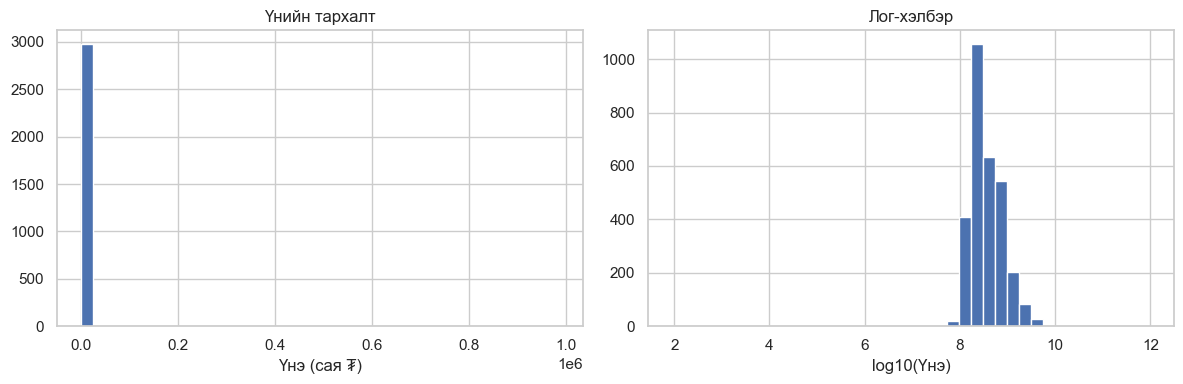

count      2976.0
mean        905.9
std       18503.2
min           0.0
25%         202.5
50%         303.0
75%         600.0
max      986000.0
Name: price_mnt, dtype: float64


In [6]:
# Үнэгүй мөр устгах
df = df[df['price_mnt'].notna()].copy()

# Үнийн тархалт
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price_mnt'] / 1e6, bins=40)
axes[0].set_xlabel('Үнэ (сая ₮)')
axes[0].set_title('Үнийн тархалт')
axes[1].hist(np.log10(df['price_mnt']), bins=40)
axes[1].set_xlabel('log10(Үнэ)')
axes[1].set_title('Лог-хэлбэр')
plt.tight_layout(); plt.show()

print((df['price_mnt'] / 1e6).describe().round(1))

In [7]:
# Худалдааны үнийн доод/дээд хязгаар
# Доод: 30 сая ₮ — энэнээс доош ихэнхдээ түрээс эсвэл алдаа
# Дээд: 5 тэрбум ₮ — энэнээс дээш ховор бөгөөд outlier нөлөөлдөг
MIN_PRICE = 30_000_000
MAX_PRICE = 5_000_000_000

before = len(df)
df = df[(df['price_mnt'] >= MIN_PRICE) & (df['price_mnt'] <= MAX_PRICE)].copy()
print(f'Үнийн хязгаараас гадуур: {before - len(df)} мөр устгав → {len(df)} үлдсэн')

Үнийн хязгаараас гадуур: 6 мөр устгав → 2970 үлдсэн


## 4. Талбай, өрөө, оны цэвэрлэлт

In [8]:
# Талбай: 15-500 м² хооронд логик утга
before = len(df)
df = df[(df['area_m2'] >= 15) & (df['area_m2'] <= 500)].copy()
print(f'Талбайн алдаа: {before - len(df)} мөр устгав')

# Барилгын он: 1950-аас одоо хүртэл (төлөвлөгдсөн он 2027 хүртэл)
before = len(df)
df = df[df['year_built'].between(1950, 2030, inclusive='both') | df['year_built'].isna()].copy()
print(f'Оны алдаа: {before - len(df)} мөр устгав')

# Давхар нь нийт давхараас хэтрэх боломжгүй
mask = df['floor'] > df['total_floors']
print(f'Давхар > нийт давхар: {mask.sum()} мөр (зөвлөмж: үлдээж тэмдэглэе)')
df.loc[mask, ['floor', 'total_floors']] = np.nan  # эргэлзээтэй утгыг NaN болгох

print(f'\nЦэвэрлэлтийн дараа: {len(df)} зар')

Талбайн алдаа: 5 мөр устгав
Оны алдаа: 0 мөр устгав
Давхар > нийт давхар: 45 мөр (зөвлөмж: үлдээж тэмдэглэе)

Цэвэрлэлтийн дараа: 2965 зар


In [9]:
# Өрөөний тоо: title-аас задалсан, дутуу мөрийг median-аар нөхөх
df['rooms'] = df['rooms'].fillna(df.groupby(pd.cut(df['area_m2'], bins=[0,40,60,90,200,500]))['rooms'].transform('median'))
df['rooms'] = df['rooms'].fillna(df['rooms'].median())
df['rooms'] = df['rooms'].astype(int)

df['rooms'].value_counts().sort_index()

rooms
1     213
2    1122
3     991
4     419
5     177
6      33
7       6
8       3
9       1
Name: count, dtype: int64

## 5. Категорийн хувьсагч кодлох

In [10]:
# Тагттай эсэх — bool болгох
def has_balcony(s):
    if pd.isna(s): return np.nan
    s = str(s).lower()
    if 'байхгүй' in s or 'үгүй' in s: return 0
    return 1

df['has_balcony'] = df['balcony'].apply(has_balcony)
df['has_garage'] = df['garage'].apply(lambda s: 0 if pd.isna(s) or 'байхгүй' in str(s).lower() else 1)
df['has_elevator'] = df['elevator'].apply(lambda s: 1 if pd.notna(s) and 'байгаа' in str(s).lower() else 0)

# Барилгын явц — ашиглалтад орсон vs баригдаж байгаа
df['is_finished'] = df['construction_status'].apply(
    lambda s: 1 if pd.notna(s) and 'ашиглалт' in str(s).lower() else 0
)

# Тагтны тоо — "1 тагттай", "2 тагттай" гэх мэтээс тоо ялгах
df['balcony_count'] = df['balcony'].str.extract(r'(\d+)').astype(float).fillna(0).astype(int)

df[['has_balcony', 'has_garage', 'has_elevator', 'is_finished', 'balcony_count']].describe()

,has_balcony,has_garage,has_elevator,is_finished,balcony_count
count,2965.0,2965.000000,2965.0,2965.0,2965.000000
mean,1.0,0.199325,0.0,1.0,1.042833
std,0.0,0.399561,0.0,0.0,0.491342
min,1.0,0.000000,0.0,1.0,0.000000
25%,1.0,0.000000,0.0,1.0,1.000000
50%,1.0,0.000000,0.0,1.0,1.000000
75%,1.0,0.000000,0.0,1.0,1.000000
max,1.0,1.000000,0.0,1.0,3.000000


## 6. Шинэ feature нэмэх

In [11]:
CURRENT_YEAR = 2025

df['price_per_m2'] = df['price_mnt'] / df['area_m2']
df['building_age'] = (CURRENT_YEAR - df['year_built']).clip(lower=0)
df['log_price'] = np.log(df['price_mnt'])
df['floor_ratio'] = df['floor'] / df['total_floors']  # дунд давхар vs дээд давхар

df[['price_mnt', 'area_m2', 'price_per_m2', 'building_age', 'log_price']].describe().round(2)

,price_mnt,area_m2,price_per_m2,building_age,log_price
count,2.965000e+03,2965.00,2965.00,2965.00,2965.00
mean,4.983521e+08,85.15,5210549.29,7.04,19.69
std,5.436800e+08,53.99,2228657.09,8.54,0.76
min,6.000000e+07,15.00,1214285.71,0.00,17.91
25%,2.025000e+08,51.00,3777777.78,0.00,19.13
50%,3.020000e+08,69.00,4506437.77,5.00,19.53
75%,6.000000e+08,101.00,5998209.49,10.00,20.21
max,4.930000e+09,385.00,40021119.32,45.00,22.32


## 7. Дүүрэг тус бүрийн дундаж м²-ийн үнэ

In [12]:
district_stats = df.groupby('district').agg(
    n=('price_mnt', 'count'),
    median_price_m2=('price_per_m2', 'median'),
    mean_price_m2=('price_per_m2', 'mean'),
).sort_values('median_price_m2', ascending=False)
district_stats['median_price_m2'] = (district_stats['median_price_m2'] / 1e6).round(2)
district_stats['mean_price_m2'] = (district_stats['mean_price_m2'] / 1e6).round(2)
district_stats.rename(columns={'median_price_m2': 'med_m²(сая₮)', 'mean_price_m2': 'mean_m²(сая₮)'})

,n,med_m²(сая₮),mean_m²(сая₮)
district,,,
Сүхбаатар аймаг,1,5.38,5.38
Чингэлтэй,74,5.08,5.35
Сүхбаатар,368,5.00,5.61
Хан-Уул,1303,4.80,5.62
Баянзүрх,752,4.51,5.00
Баянгол,346,4.05,4.35
Орхон,3,3.90,4.19
Дархан-Уул,2,3.30,3.30
Сонгинохайрхан,109,3.18,3.26


In [13]:
# Цөөн зартай дүүргийг "Бусад" болгох (зөвхөн 30+ зартай дүүргийг үлдээх)
MIN_PER_DISTRICT = 30
counts = df['district'].value_counts()
rare_districts = counts[counts < MIN_PER_DISTRICT].index
df['district_grouped'] = df['district'].where(~df['district'].isin(rare_districts), 'Бусад')
df['district_grouped'].value_counts()

district_grouped
Хан-Уул           1303
Баянзүрх           752
Сүхбаатар          368
Баянгол            346
Сонгинохайрхан     109
Чингэлтэй           74
Бусад               13
Name: count, dtype: int64

## 8. Эцсийн шалгалт ба хадгалах

In [14]:
# Загварчлалд хэрэгтэй баганууд
MODEL_COLS = [
    'price_mnt', 'log_price',
    'area_m2', 'rooms', 'floor', 'total_floors', 'floor_ratio',
    'building_age', 'year_built',
    'has_balcony', 'balcony_count', 'has_garage', 'has_elevator', 'is_finished',
    'district', 'district_grouped',
    'window_type', 'door_type', 'floor_material',
    'price_per_m2',
]

df_model = df[MODEL_COLS].copy()
print(f'Эцсийн өгөгдөл: {df_model.shape}')
print(f'\nДутуу утга:')
print(df_model.isna().sum()[df_model.isna().sum() > 0])

Эцсийн өгөгдөл: (2965, 20)

Дутуу утга:
floor           45
total_floors    45
floor_ratio     45
dtype: int64


In [15]:
df_model.to_csv(OUT_PATH, index=False)
print(f'Хадгаллаа → {OUT_PATH}')
print(f'Хэмжээ: {len(df_model)} мөр × {len(df_model.columns)} багана')

Хадгаллаа → ../data/listings_clean.csv
Хэмжээ: 2965 мөр × 20 багана


## Дүгнэлт

Цэвэр өгөгдлийг `data/listings_clean.csv` файлд хадгаллаа. Дараагийн алхамд:

- **`03_eda.ipynb`** — өгөгдлийн дотоод бүтцийг судлах (корреляц, scatter, boxplot)
- **`04_models.ipynb`** — Шугаман регресс, Lasso, Шийдвэрийн мод, Random Forest харьцуулах